In [1]:
pip install pandas matplotlib streamlit plotly openpyxl

Note: you may need to restart the kernel to use updated packages.


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore') 
plt.style.use('seaborn-v0_8-whitegrid') 
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [41]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\17840\ACC102-project
['.ipynb_checkpoints', 'app.py', 'Botao Gong.ipynb', 'FAOSTAT_data_en_4-19-2026_2.csv', 'FAOSTAT_data_en_4-19-2026__1.csv', 'fig1_food_price_trend.png', 'fig2_subindices.png', 'fig3_cpi_trends.png', 'fig4_correlation.png', 'fig5_lag_analysis.png', 'fig6_food_vs_general_cpi.png', 'fig7_ukraine_war_impact.png', 'food_price_indices_data.csv']


In [42]:
fao_raw = pd.read_csv('food_price_indices_data.csv', skiprows=2)
fao = fao_raw[['Date', 'Food Price Index', 'Meat', 'Dairy', 'Cereals', 'Oils', 'Sugar']].copy()
fao = fao.dropna(subset=['Date']) 
fao['Date'] = pd.to_datetime(fao['Date'], format='%Y-%m')
for col in ['Food Price Index', 'Meat', 'Dairy', 'Cereals', 'Oils', 'Sugar']:
    fao[col] = pd.to_numeric(fao[col], errors='coerce') 
fao = fao[fao['Date'] >= '2000-01-01'].reset_index(drop=True)

print(f'FAO loaded: {len(fao)} rows')
print(f'Date range: {fao["Date"].min().strftime("%Y-%m")} to {fao["Date"].max().strftime("%Y-%m")}')
fao.head()

FAO loaded: 315 rows
Date range: 2000-01 to 2026-03


,Date,Food Price Index,Meat,Dairy,Cereals,Oils,Sugar
0,2000-01-01,52.8,60.6,50.2,52.1,48.58,34.7
1,2000-02-01,52.5,60.9,50.4,52.2,46.37,32.7
2,2000-03-01,53.1,62.8,50.1,51.7,47.82,31.8
3,2000-04-01,53.7,62.3,50.4,51.8,49.50,37.3
4,2000-05-01,54.0,63.3,50.9,52.8,44.49,42.8


In [24]:
cpi_raw = pd.read_csv('FAOSTAT_data_en_4-19-2026_2.csv')

month_map = {
    'January':1,'February':2,'March':3,'April':4,
    'May':5,'June':6,'July':7,'August':8,
    'September':9,'October':10,'November':11,'December':12
}

country_rename = {
    'China, mainland': 'China',
    'United States of America': 'USA',
    'Russian Federation': 'Russia',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom'
}

print(f'CPI raw rows: {len(cpi_raw)}')
print(f'Countries: {sorted(cpi_raw["Area"].unique())}')

CPI raw rows: 12788
Countries: ['Australia', 'Brazil', 'China, mainland', 'France', 'Germany', 'India', 'Indonesia', 'Japan', 'Mexico', 'Russian Federation', 'South Africa', 'Thailand', 'United Kingdom of Great Britain and Northern Ireland', 'United States of America']


In [25]:
cpi_general = cpi_raw[cpi_raw['Item'] == 'Consumer Prices, General Indices (2015 = 100)'].copy()
cpi_general['Month_Num'] = cpi_general['Months'].map(month_map)
cpi_general['Date'] = pd.to_datetime(
    cpi_general['Year'].astype(str) + '-' + cpi_general['Month_Num'].astype(str), format='%Y-%m'
)
cpi_general = cpi_general.rename(columns={'Area': 'Country', 'Value': 'CPI'})
cpi_general['Country'] = cpi_general['Country'].replace(country_rename)
cpi_general = cpi_general[['Country', 'Date', 'CPI']].dropna()
cpi_pivot = cpi_general.pivot_table(index='Date', columns='Country', values='CPI').sort_index()

cpi_food = cpi_raw[cpi_raw['Item'] == 'Consumer Prices, Food Indices (2015 = 100)'].copy()
cpi_food['Month_Num'] = cpi_food['Months'].map(month_map)
cpi_food['Date'] = pd.to_datetime(
    cpi_food['Year'].astype(str) + '-' + cpi_food['Month_Num'].astype(str), format='%Y-%m'
)
cpi_food = cpi_food.rename(columns={'Area': 'Country', 'Value': 'Food_CPI'})
cpi_food['Country'] = cpi_food['Country'].replace(country_rename)
cpi_food = cpi_food[['Country', 'Date', 'Food_CPI']].dropna()
cpi_food_pivot = cpi_food.pivot_table(index='Date', columns='Country', values='Food_CPI').sort_index()

print(f'General CPI shape: {cpi_pivot.shape}')
print(f'Food CPI shape: {cpi_food_pivot.shape}')
print(f'Countries: {list(cpi_pivot.columns)}')

General CPI shape: (309, 14)
Food CPI shape: (309, 14)
Countries: ['Australia', 'Brazil', 'China', 'France', 'Germany', 'India', 'Indonesia', 'Japan', 'Mexico', 'Russia', 'South Africa', 'Thailand', 'USA', 'United Kingdom']


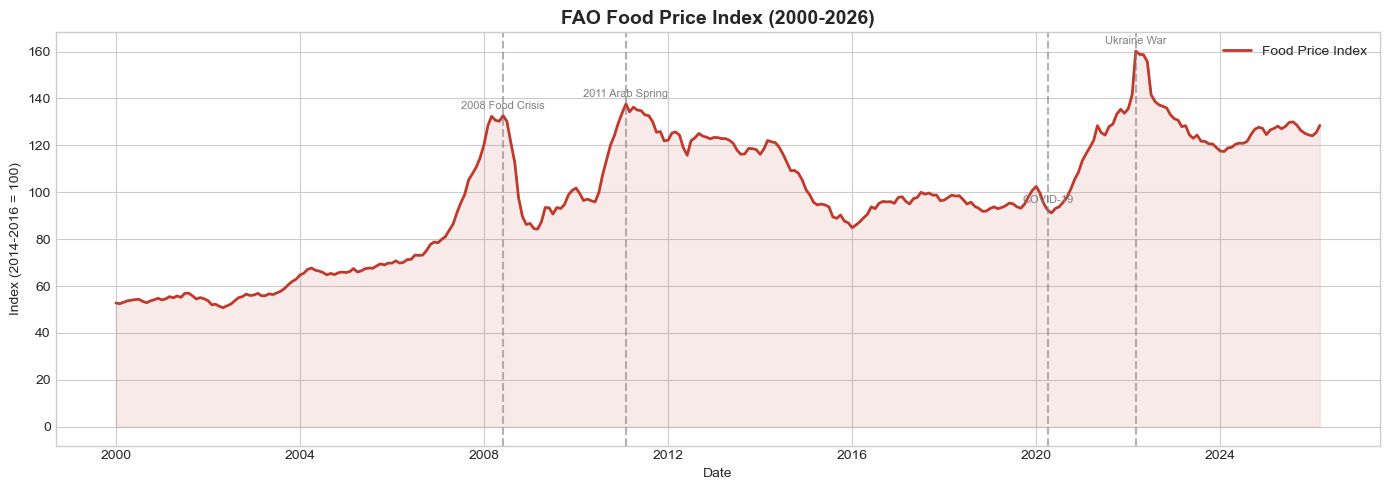

In [26]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(fao['Date'], fao['Food Price Index'], color='#c0392b', linewidth=2, label='Food Price Index')
ax.fill_between(fao['Date'], fao['Food Price Index'], alpha=0.1, color='#c0392b')

events = {'2008-06': '2008 Food Crisis', '2011-02': '2011 Arab Spring', '2020-04': 'COVID-19', '2022-03': 'Ukraine War'}
for date_str, label in events.items():
    date = pd.to_datetime(date_str)
    val = fao.loc[fao['Date'] == date, 'Food Price Index']
    if not val.empty:
        ax.axvline(x=date, color='gray', linestyle='--', alpha=0.6)
        ax.text(date, val.values[0] + 3, label, fontsize=8, ha='center', color='gray')

ax.set_title('FAO Food Price Index (2000-2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Index (2014-2016 = 100)')
ax.legend()
plt.tight_layout()
plt.savefig('fig1_food_price_trend.png', dpi=150)
plt.show()

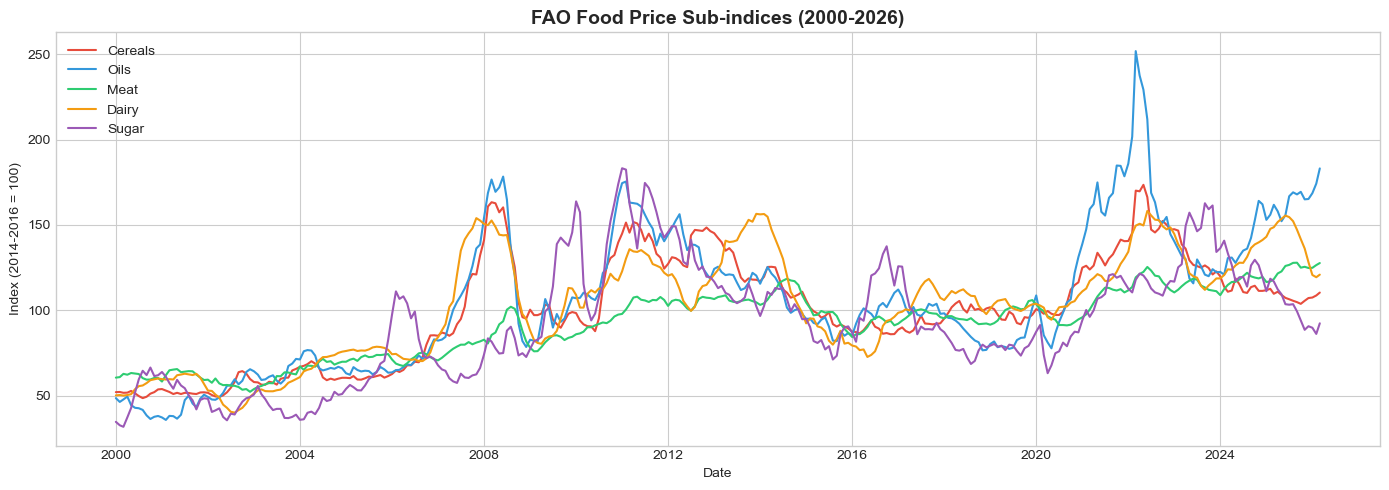

In [27]:
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
for col, color in zip(['Cereals', 'Oils', 'Meat', 'Dairy', 'Sugar'], colors):
    ax.plot(fao['Date'], fao[col], label=col, linewidth=1.5, color=color)

ax.set_title('FAO Food Price Sub-indices (2000-2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Index (2014-2016 = 100)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('fig2_subindices.png', dpi=150)
plt.show()

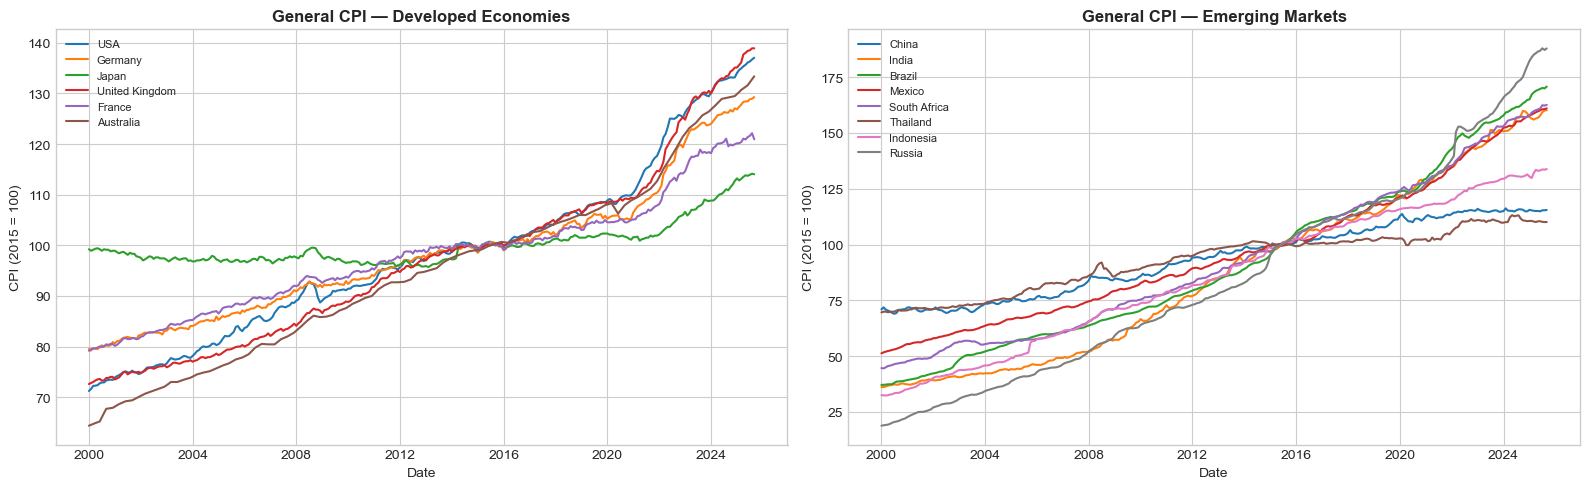

In [28]:
developed = ['USA', 'Germany', 'Japan', 'United Kingdom', 'France', 'Australia']
emerging = ['China', 'India', 'Brazil', 'Mexico', 'South Africa', 'Thailand', 'Indonesia', 'Russia']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, group, title in zip(axes, [developed, emerging], ['Developed Economies', 'Emerging Markets']):
    for country in group:
        if country in cpi_pivot.columns:
            ax.plot(cpi_pivot.index, cpi_pivot[country], label=country, linewidth=1.5)
    ax.set_title(f'General CPI — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('CPI (2015 = 100)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig3_cpi_trends.png', dpi=150)
plt.show()

In [29]:
fao_change = fao.set_index('Date')[['Food Price Index']].pct_change() * 100
fao_change.columns = ['FAO_pct']
cpi_change = cpi_pivot.pct_change() * 100
merged = fao_change.join(cpi_change, how='inner').dropna()
countries = [c for c in cpi_pivot.columns if c in merged.columns]

corr_values = {c: round(merged['FAO_pct'].corr(merged[c]), 3) for c in countries}
corr_df = pd.DataFrame.from_dict(corr_values, orient='index', columns=['Correlation'])
corr_df = corr_df.sort_values('Correlation', ascending=False)
print('Correlation between FAO Food Price Index and national CPI:')
print(corr_df)

Correlation between FAO Food Price Index and national CPI:
                Correlation
USA                   0.314
Thailand              0.270
China                 0.172
Russia                0.168
Germany               0.163
France                0.140
Brazil                0.138
Australia             0.105
United Kingdom        0.081
India                 0.073
Indonesia             0.042
Mexico                0.007
Japan                -0.011
South Africa         -0.043


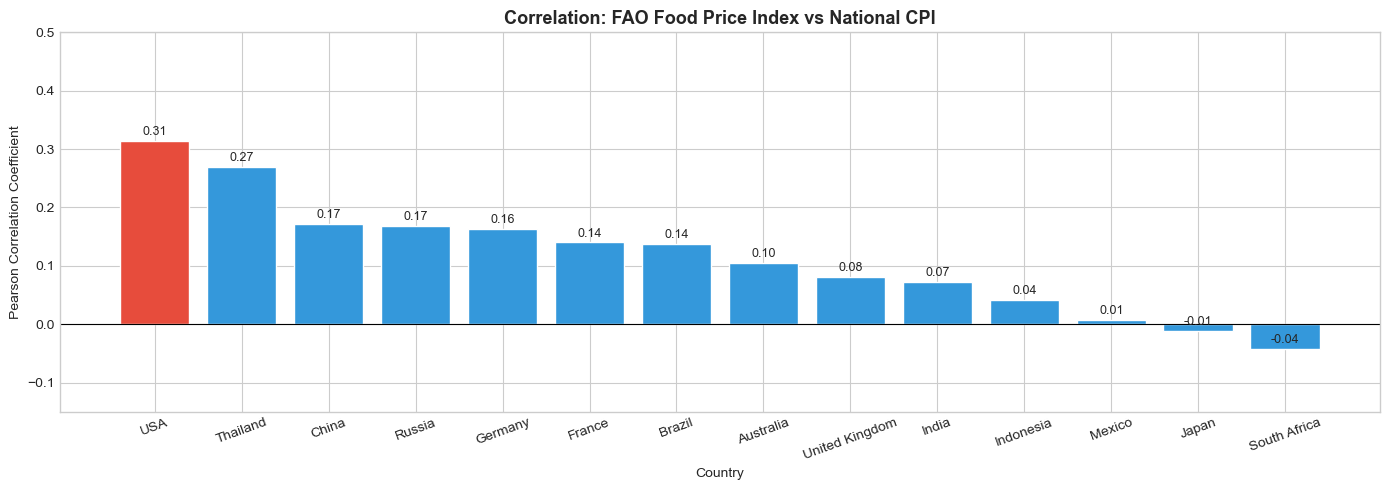

In [30]:
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#e74c3c' if v > 0.3 else '#3498db' for v in corr_df['Correlation']]
bars = ax.bar(corr_df.index, corr_df['Correlation'], color=colors, edgecolor='white')
for bar, val in zip(bars, corr_df['Correlation']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Correlation: FAO Food Price Index vs National CPI', fontsize=13, fontweight='bold')
ax.set_ylabel('Pearson Correlation Coefficient')
ax.set_xlabel('Country')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylim(-0.15, 0.5)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('fig4_correlation.png', dpi=150)
plt.show()

In [31]:
lag_months = [0, 3, 6, 12]
lag_results = {}
for country in countries:
    lag_results[country] = {}
    for lag in lag_months:
        corr = merged['FAO_pct'].shift(lag).corr(merged[country])
        lag_results[country][f'Lag {lag}m'] = round(corr, 3)

lag_df = pd.DataFrame(lag_results).T
print('Correlation at different lag periods:')
print(lag_df)

Correlation at different lag periods:
                Lag 0m  Lag 3m  Lag 6m  Lag 12m
Australia        0.105   0.181   0.162    0.068
Brazil           0.138   0.106  -0.058    0.056
China            0.172   0.141   0.058   -0.016
France           0.140   0.081   0.053    0.098
Germany          0.163   0.059   0.127    0.128
India            0.073   0.018   0.009   -0.033
Indonesia        0.042   0.050   0.040    0.064
Japan           -0.011   0.038   0.107    0.032
Mexico           0.007  -0.009   0.055    0.060
Russia           0.168  -0.024  -0.020    0.096
South Africa    -0.043   0.023   0.001    0.069
Thailand         0.270   0.159   0.052    0.041
USA              0.314   0.219   0.106    0.064
United Kingdom   0.081   0.093   0.153    0.160


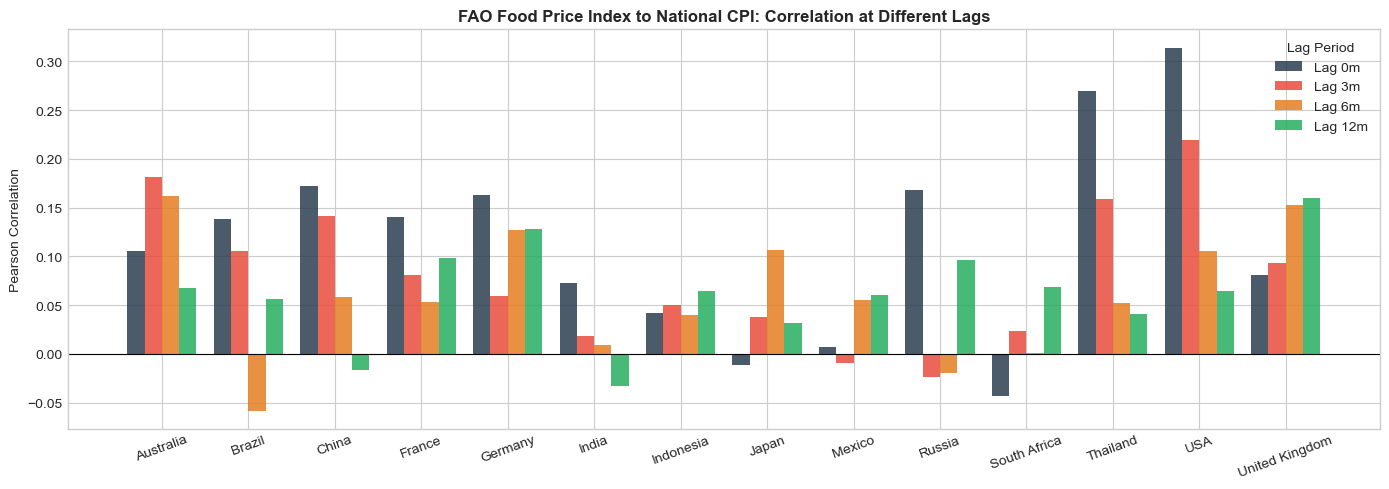

In [32]:
fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(lag_df))
width = 0.2
lag_colors = ['#2c3e50', '#e74c3c', '#e67e22', '#27ae60']
for i, (lag_col, color) in enumerate(zip(lag_df.columns, lag_colors)):
    offset = (i - 1.5) * width
    ax.bar([xi + offset for xi in x], lag_df[lag_col], width=width, label=lag_col, color=color, alpha=0.85)
ax.set_title('FAO Food Price Index to National CPI: Correlation at Different Lags', fontsize=12, fontweight='bold')
ax.set_ylabel('Pearson Correlation')
ax.set_xticks(list(x))
ax.set_xticklabels(lag_df.index, rotation=20)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.legend(title='Lag Period')
plt.tight_layout()
plt.savefig('fig5_lag_analysis.png', dpi=150)
plt.show()

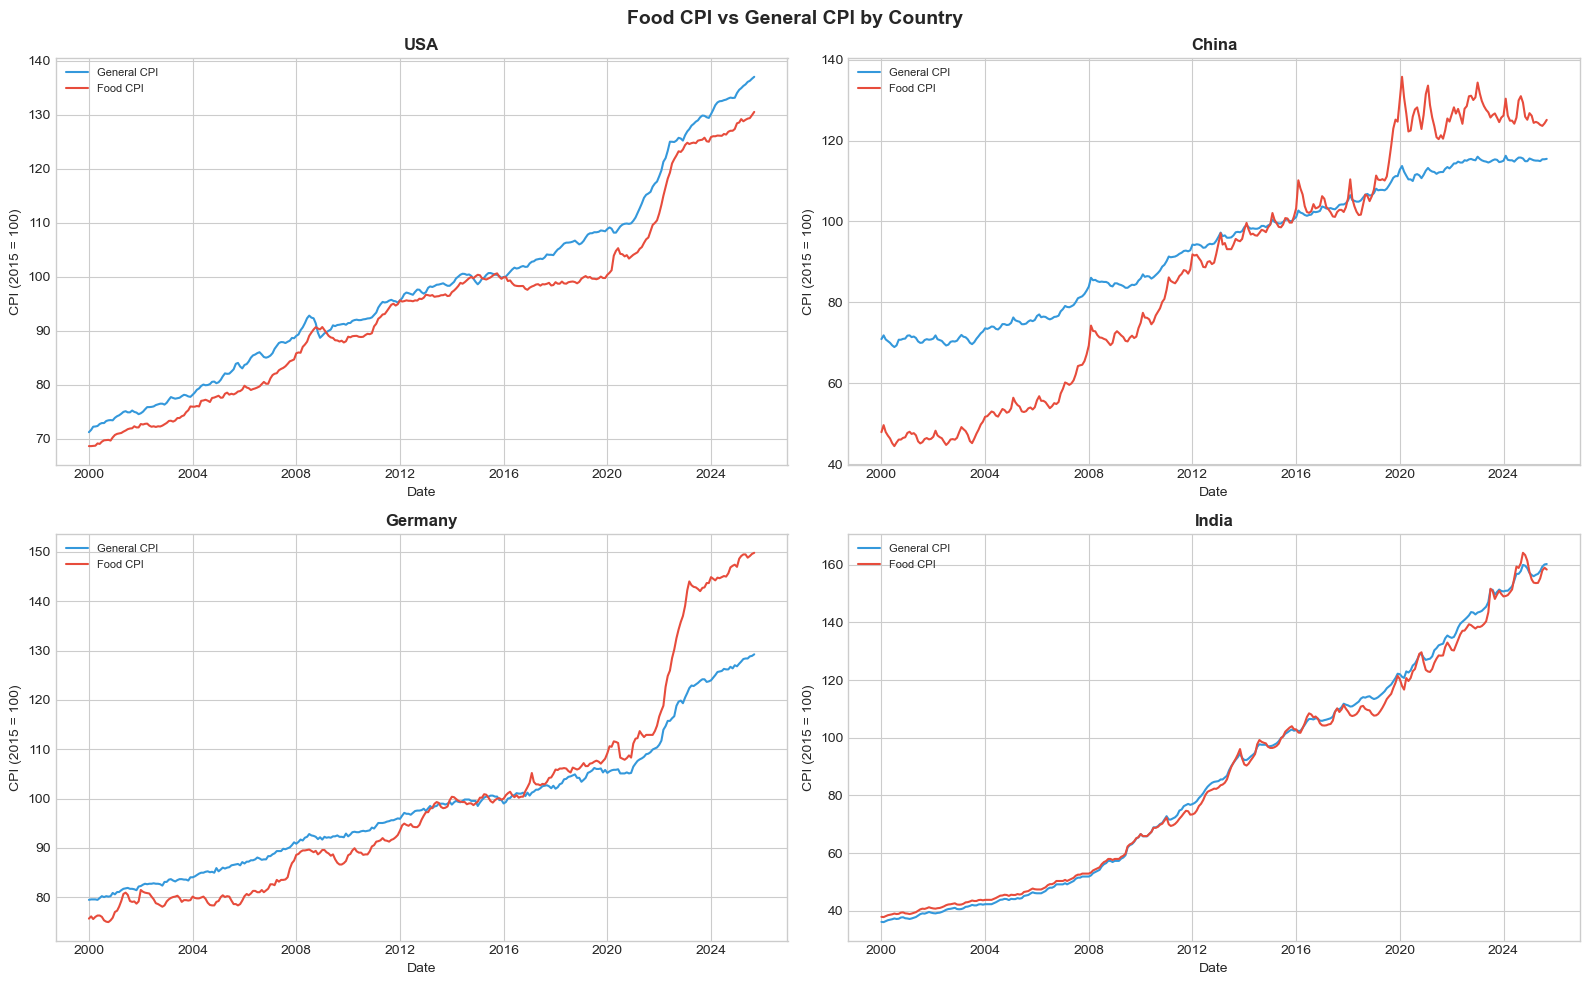

In [33]:
sample_countries = ['USA', 'China', 'Germany', 'India']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, country in zip(axes.flatten(), sample_countries):
    if country in cpi_pivot.columns and country in cpi_food_pivot.columns:
        gen = cpi_pivot[country].dropna()
        food = cpi_food_pivot[country].dropna()
        ax.plot(gen.index, gen.values, label='General CPI', color='#3498db', linewidth=1.5)
        ax.plot(food.index, food.values, label='Food CPI', color='#e74c3c', linewidth=1.5)
        ax.set_title(country, fontsize=12, fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('CPI (2015 = 100)')
        ax.legend(fontsize=8)

plt.suptitle('Food CPI vs General CPI by Country', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_food_vs_general_cpi.png', dpi=150)
plt.show()

In [35]:
war_date = pd.to_datetime('2022-03-01')
pre_start = pd.to_datetime('2021-03-01')
post_end = pd.to_datetime('2023-03-01')

war_impact = {}
for country in cpi_pivot.columns:
    pre = cpi_pivot.loc[(cpi_pivot.index >= pre_start) & (cpi_pivot.index < war_date), country].mean()
    post = cpi_pivot.loc[(cpi_pivot.index >= war_date) & (cpi_pivot.index <= post_end), country].mean()
    if pd.notna(pre) and pd.notna(post) and pre != 0:
        war_impact[country] = round(((post - pre) / pre) * 100, 2)

impact_df = pd.DataFrame.from_dict(war_impact, orient='index', columns=['CPI Change (%)'])
impact_df = impact_df.sort_values('CPI Change (%)', ascending=False)
print('CPI Change after Ukraine War:')
print(impact_df)

CPI Change after Ukraine War:
                CPI Change (%)
Russia                   14.29
United Kingdom            8.87
Brazil                    8.71
Mexico                    8.28
Germany                   7.93
USA                       7.92
South Africa              7.59
Australia                 7.05
India                     6.92
Thailand                  6.17
France                    5.96
Indonesia                 4.92
Japan                     3.14
China                     2.06


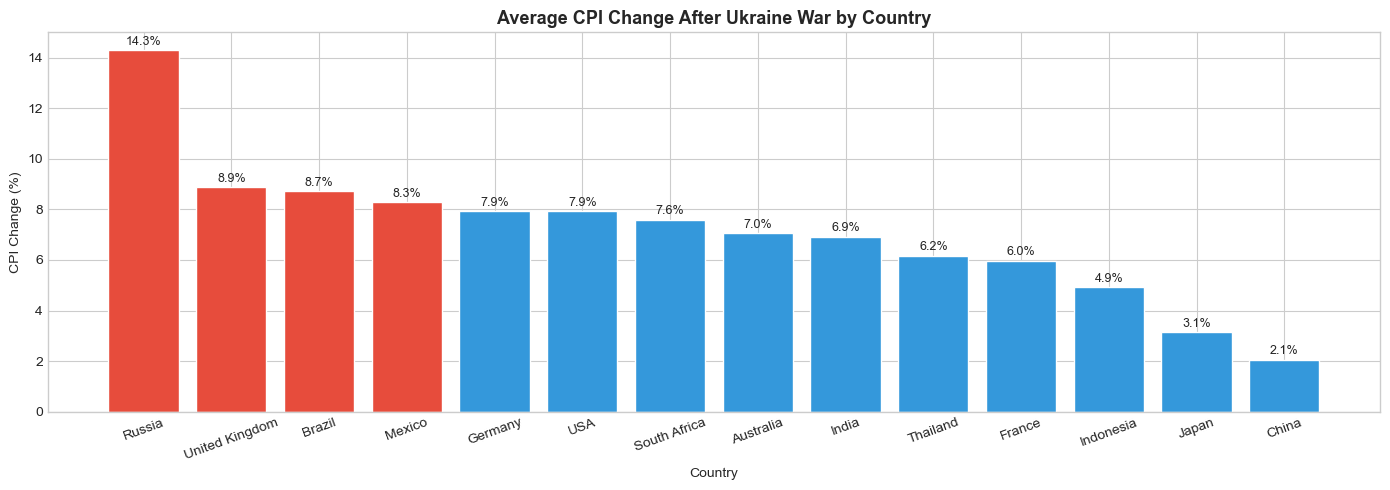

In [36]:
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#e74c3c' if v > 8 else '#3498db' for v in impact_df['CPI Change (%)']]
bars = ax.bar(impact_df.index, impact_df['CPI Change (%)'], color=colors, edgecolor='white')
for bar, val in zip(bars, impact_df['CPI Change (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_title('Average CPI Change After Ukraine War by Country', fontsize=13, fontweight='bold')
ax.set_ylabel('CPI Change (%)')
ax.set_xlabel('Country')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('fig7_ukraine_war_impact.png', dpi=150)
plt.show()

In [37]:
print('=' * 65)
print('KEY FINDINGS SUMMARY')
print('=' * 65)

top_country = corr_df['Correlation'].idxmax()
top_corr = corr_df['Correlation'].max()
print(f'\n1. Strongest correlation with FAO Food Price Index:')
print(f'   {top_country} (r = {top_corr})')

bot_country = corr_df['Correlation'].idxmin()
bot_corr = corr_df['Correlation'].min()
print(f'\n2. Weakest correlation:')
print(f'   {bot_country} (r = {bot_corr})')

print(f'\n3. Optimal lag period per country:')
for country in lag_df.index:
    best_lag = lag_df.loc[country].idxmax()
    best_val = lag_df.loc[country].max()
    print(f'   {country}: {best_lag} (r = {best_val})')

top_war = impact_df['CPI Change (%)'].idxmax()
top_war_val = impact_df['CPI Change (%)'].max()
print(f'\n4. Largest CPI increase after Ukraine War:')
print(f'   {top_war}: +{top_war_val}%')

print('\n' + '=' * 65)
print('Data Sources:')
print('  FAO Food Price Index: https://www.fao.org/worldfoodsituation/foodpricesindex/en/')
print('  FAOSTAT CPI Data:     https://www.fao.org/faostat/en/#data/CP')
print('  Both accessed: 19 April 2026')
print('=' * 65)

KEY FINDINGS SUMMARY

1. Strongest correlation with FAO Food Price Index:
   USA (r = 0.314)

2. Weakest correlation:
   South Africa (r = -0.043)

3. Optimal lag period per country:
   Australia: Lag 3m (r = 0.181)
   Brazil: Lag 0m (r = 0.138)
   China: Lag 0m (r = 0.172)
   France: Lag 0m (r = 0.14)
   Germany: Lag 0m (r = 0.163)
   India: Lag 0m (r = 0.073)
   Indonesia: Lag 12m (r = 0.064)
   Japan: Lag 6m (r = 0.107)
   Mexico: Lag 12m (r = 0.06)
   Russia: Lag 0m (r = 0.168)
   South Africa: Lag 12m (r = 0.069)
   Thailand: Lag 0m (r = 0.27)
   USA: Lag 0m (r = 0.314)
   United Kingdom: Lag 12m (r = 0.16)

4. Largest CPI increase after Ukraine War:
   Russia: +14.29%

Data Sources:
  FAO Food Price Index: https://www.fao.org/worldfoodsituation/foodpricesindex/en/
  FAOSTAT CPI Data:     https://www.fao.org/faostat/en/#data/CP
  Both accessed: 19 April 2026
